# Movie Ratings Mini Analysis

## Project Goal
The goal of this project is to explore movie ratings using Python and basic data analysis techniques.

In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/movies.csv")

In [5]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [6]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [7]:
df = df[['Series_Title', 'Released_Year', 'IMDB_Rating', 'Genre', 'Runtime']]
df.head()

,Series_Title,Released_Year,IMDB_Rating,Genre,Runtime
0,The Shawshank Redemption,1994,9.3,Drama,142 min
1,The Godfather,1972,9.2,"Crime, Drama",175 min
2,The Dark Knight,2008,9.0,"Action, Crime, Drama",152 min
3,The Godfather: Part II,1974,9.0,"Crime, Drama",202 min
4,12 Angry Men,1957,9.0,"Crime, Drama",96 min


In [8]:
df['Runtime'] = df['Runtime'].str.replace(' min', '')
df['Runtime'] = df['Runtime'].astype(int)

df.head()

,Series_Title,Released_Year,IMDB_Rating,Genre,Runtime
0,The Shawshank Redemption,1994,9.3,Drama,142
1,The Godfather,1972,9.2,"Crime, Drama",175
2,The Dark Knight,2008,9.0,"Action, Crime, Drama",152
3,The Godfather: Part II,1974,9.0,"Crime, Drama",202
4,12 Angry Men,1957,9.0,"Crime, Drama",96


In [9]:
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

df.head()

,Series_Title,Released_Year,IMDB_Rating,Genre,Runtime
0,The Shawshank Redemption,1994.0,9.3,Drama,142
1,The Godfather,1972.0,9.2,"Crime, Drama",175
2,The Dark Knight,2008.0,9.0,"Action, Crime, Drama",152
3,The Godfather: Part II,1974.0,9.0,"Crime, Drama",202
4,12 Angry Men,1957.0,9.0,"Crime, Drama",96


In [10]:
df['IMDB_Rating'] = pd.to_numeric(df['IMDB_Rating'], errors='coerce')
df = df.dropna(subset=['IMDB_Rating'])

df.head()

,Series_Title,Released_Year,IMDB_Rating,Genre,Runtime
0,The Shawshank Redemption,1994.0,9.3,Drama,142
1,The Godfather,1972.0,9.2,"Crime, Drama",175
2,The Dark Knight,2008.0,9.0,"Action, Crime, Drama",152
3,The Godfather: Part II,1974.0,9.0,"Crime, Drama",202
4,12 Angry Men,1957.0,9.0,"Crime, Drama",96


In [11]:
df.shape, df['IMDB_Rating'].mean()

((1000, 5), np.float64(7.949299999999999))

In [12]:
avg_rating = df['IMDB_Rating'].mean()
round(avg_rating, 2)

np.float64(7.95)

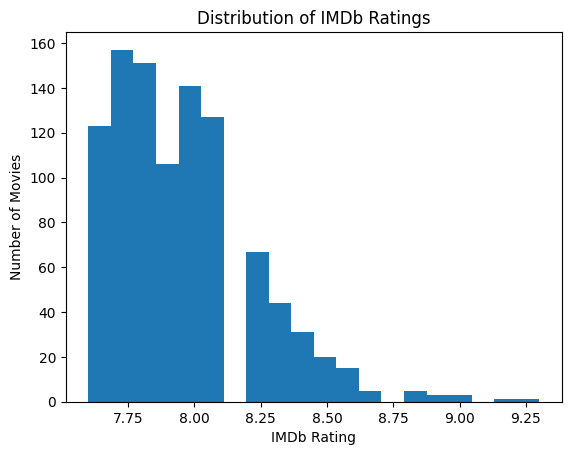

In [14]:
import matplotlib.pyplot as plt

plt.hist(df['IMDB_Rating'], bins=20)
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of IMDb Ratings")

plt.show()

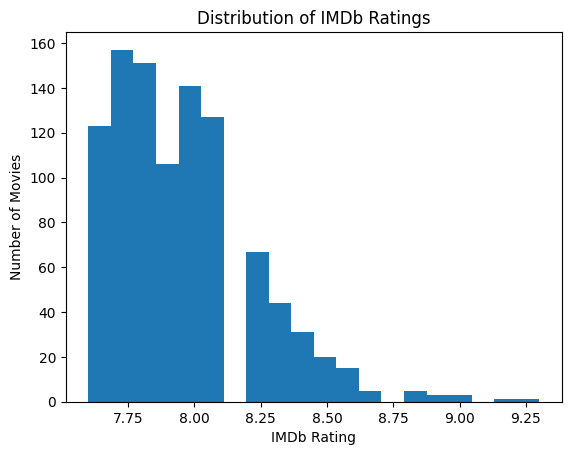

In [16]:
plt.hist(df['IMDB_Rating'], bins=20)
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of IMDb Ratings")

plt.savefig("../images/ratings_distribution.png") # saves the histogram as an image
plt.show()

In [17]:
avg_rating = round(df['IMDB_Rating'].mean(), 2)
avg_rating

np.float64(7.95)

## Question 1: What is the average IMDb rating?

The average IMDb rating of movies in this dataset is approximately **7.95**.

In [19]:
df['Decade'] = (df['Released_Year'] // 10) * 10
df[['Released_Year', 'Decade']].head()

,Released_Year,Decade
0,1994.0,1990.0
1,1972.0,1970.0
2,2008.0,2000.0
3,1974.0,1970.0
4,1957.0,1950.0


In [20]:
avg_by_decade = df.groupby('Decade')['IMDB_Rating'].mean()

avg_by_decade

Decade
1920.0    8.127273
1930.0    7.966667
1940.0    8.025714
1950.0    8.058929
1960.0    7.973973
1970.0    7.969737
1980.0    7.953933
1990.0    7.963333
2000.0    7.899578
2010.0    7.924380
2020.0    8.133333
Name: IMDB_Rating, dtype: float64

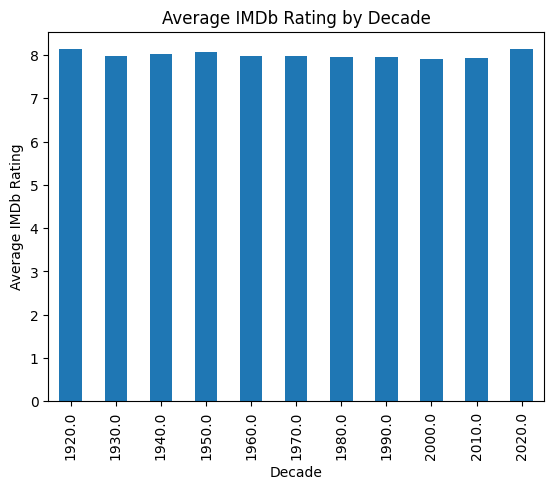

In [21]:
avg_by_decade.plot(kind='bar')

plt.xlabel("Decade")
plt.ylabel("Average IMDb Rating")
plt.title("Average IMDb Rating by Decade")

plt.savefig("../images/avg_ratings_by_decade.png")
plt.show()

## Question 2: Do IMDb ratings change over time?

The average IMDb rating stays fairly consistent across decades generally randing between about 7.9 and 8.1.

There is no strong upward or doownward trend over time, although some decades (such as the 1920s and 2020s) show slightly higher average ratings.

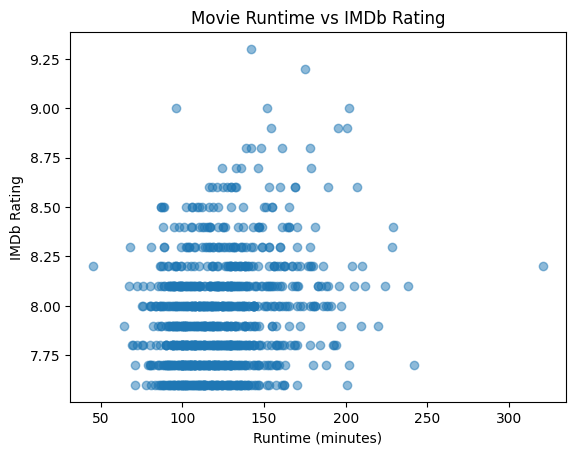

In [22]:
plt.scatter(df['Runtime'], df['IMDB_Rating'], alpha=0.5)

plt.xlabel("Runtime (minutes)")
plt.ylabel("IMDb Rating")
plt.title("Movie Runtime vs IMDb Rating")

plt.savefig("../images/runtime_vs_rating.png")
plt.show()

## Conclusion

In this project, I explored IMDb movie ratings using basic Python data analysis techniques.  
I found that the average IMDb rating in this dataset is around 7.95 and that ratings remain fairly consistent across decades.  
The analysis also suggests that movie runtime does not have a strong relationship with IMDb rating.

This project helped me practice working with real-world data, cleaning datasets, creating visualizations, and explaining results in plain language.